# Project 2 Workbook: LendingClub XAI Professional Model Audit

This is the student workbook for the 2-week XAI project.

Primary dataset: LendingClub loan data.

Your goal is not only to build a strong model, but to audit how it behaves and where it fails.

## Submission Rules (Read First)

This workbook is graded on model quality plus audit quality.

Required:
1. M1 model artifact + validation metrics.
2. M2 local explanations for at least 3 failures (FP/FN).
3. M3 global dependency/interaction evidence.
4. M4 slicing analysis and mitigation proposal.

Coding expectation:
- Cells marked with `TODO REQUIRED` must be implemented by students.
- Do not leave placeholder defaults in required TODO blocks.

Not allowed:
- Plot dumping without interpretation.
- Claiming bias/fairness without subgroup metrics.
- Tuning on test set.

## Milestone Map

- M1: Black Box Model (performance first)
- M2: Local Detective (3 failure explanations)
- M3: Global Audit (importance, PDP, interactions)
- M4: Slicing + Audit Report (where model fails by subgroup and what to fix)

In [92]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import shap
from lime.lime_tabular import LimeTabularExplainer
from lightgbm import LGBMClassifier
import joblib

RANDOM_SEED = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 140)

## Team Configuration (Fill This)

Set your team metadata and assumptions before modeling.

In [93]:
team_id = 'Group 12'
audit_focus = 'Investigate potential unfair false negative rates across applicant groups'
threshold = 0.3  # You must justify and can update later using validation set

print('Team:', team_id)
print('Audit focus:', audit_focus)
print('Initial threshold:', threshold)

Team: Group 12
Audit focus: Investigate potential unfair false negative rates across applicant groups
Initial threshold: 0.3


## Part 1: Load LendingClub Data

Expected file location:
- data/lendingclub_loan_data.csv

If your file name is different, change DATA_FILE below.

In [94]:
DATA_DIR = Path('data')
DATA_FILE = DATA_DIR / 'lendingclub_loan_data.csv'

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f'Required LendingClub file not found: {DATA_FILE}. Place the CSV in project 2/data.'
    )

df_raw = pd.read_csv(DATA_FILE)
print('Loaded:', DATA_FILE)
print('Shape:', df_raw.shape)
display(df_raw.head(3))

Loaded: data\lendingclub_loan_data.csv
Shape: (9578, 15)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,loan_status
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,Fully Paid
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,Fully Paid
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,Fully Paid


## Part 2: Build Target and Core Features

Target for this workbook:
- `y = 1` for risky outcome (charged off/default/late-style statuses)

TODO (analysis-focused):
1. Inspect and print your dataset-specific `loan_status` values.
2. Complete risky label mapping for your file version.
3. Expand leakage filtering with justified columns.
4. Optional: add engineered features only if they improve explanation clarity.

In [95]:
df = df_raw.copy()

if 'loan_status' not in df.columns:
    raise ValueError('Expected a loan_status column in LendingClub dataset.')

# Inspect label space and keep this output in your report appendix.
status = df['loan_status'].astype(str).str.lower().str.strip()
display(status.value_counts(dropna=False).head(20))

# Expand risky token list only if your LendingClub file uses additional risky labels.
risky_tokens = [
    'charged off',
    'default',
    # 'late (31-120 days)',
    # 'does not meet the credit policy. status:charged off',
]
y = status.apply(lambda s: int(any(tok in s for tok in risky_tokens)))

# Starter leakage filters: add/remove based on your schema and explain choices in markdown.
leak_tokens = [
    'recover',
    'collection',
    'last_pymnt',
    'next_pymnt',
    'settlement',
    'not.fully.paid' #After first running M1 M2 and seeing this as leakage
]
feature_cols = []
for c in df.columns:
    lc = c.lower()
    if c == 'loan_status':
        continue
    if any(tok in lc for tok in leak_tokens):
        continue
    feature_cols.append(c)

X = df[feature_cols].copy()

print('Positive rate:', round(float(y.mean()), 4))
print('Features:', X.shape[1])
display(X.head(2))

loan_status
fully paid     8045
charged off    1533
Name: count, dtype: int64

Positive rate: 0.1601
Features: 13


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0


In [96]:
# Optional: sample rows for faster iteration on student laptops.
MAX_ROWS = 120000
if len(X) > MAX_ROWS:
    idx = np.random.default_rng(RANDOM_SEED).choice(len(X), size=MAX_ROWS, replace=False)
    X = X.iloc[idx].reset_index(drop=True)
    y = y.iloc[idx].reset_index(drop=True)

print('Working rows:', len(X))

Working rows: 9578


### Leakage Control
We first ran M1 and M2 without excluding not.fully.paid, leading to perfect F1 = 1.0 which identified that there might be leakage. Runnning SHAP in M2 identified that this was due to not.fully.paid. Below there is also a cross tab to showcase the direct overlap.

In [97]:
pd.crosstab(y, df_raw['not.fully.paid'], rownames=['y'], colnames=['not.fully.paid'])

not.fully.paid,0,1
y,,
0,8045,0
1,0,1533


## Part 3: Train / Validation / Test Split

In [98]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_SEED, stratify=y_train_val
)

print('Train:', len(X_train), 'Val:', len(X_val), 'Test:', len(X_test))
print('Rates train/val/test:', round(float(y_train.mean()),4), round(float(y_val.mean()),4), round(float(y_test.mean()),4))

Train: 5746 Val: 1916 Test: 1916
Rates train/val/test: 0.1599 0.1602 0.1602


## M1: The Black Box

Deliverable requirements:
1. Train one strong baseline model (provided LightGBM config is enough).
2. Report validation AUC and F1 at your chosen threshold.
3. Save model artifact (`.pkl`).
4. Write 3-5 lines on threshold trade-offs and error types.

Note: Hyperparameter tuning is optional, not required. Prioritize explanation depth in M2-M4.

In [99]:
numeric_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

# TODO REQUIRED: Build the preprocessing pipeline.
# Hint:
# 1) Numeric pipeline: median imputer
# 2) Categorical pipeline: most_frequent imputer + OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
# Numeric pipeline
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median'))])
# Categorical pipeline
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
('encoder', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))])


preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# TODO REQUIRED: Fit transform on train, transform on val/test.
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

feature_names = numeric_cols + categorical_cols

if preprocessor is None or X_train_t is None or X_val_t is None or X_test_t is None:
    raise NotImplementedError('Complete TODO REQUIRED preprocessing block before continuing.')

In [100]:
# Baseline model config (sufficient for this project).
params = {
    'n_estimators': 300,
    'learning_rate': 0.05,
    'max_depth': -1,
    'subsample': 0.9,
    'colsample_bytree': 0.8,
    'random_state': RANDOM_SEED,
}

model = LGBMClassifier(**params)
model.fit(X_train_t, y_train)

val_proba = model.predict_proba(X_val_t)[:, 1]

# TODO REQUIRED: Implement threshold comparison table on validation set.
# Required output columns: threshold, f1, positive_prediction_rate
threshold_grid = [0.3, 0.4, 0.5, 0.6]
rows = []

for t in threshold_grid:
    pred = (val_proba >= t).astype(int)

    rows.append({
        'threshold': t,
        'f1': f1_score(y_val, pred),
        'positive_prediction_rate': pred.mean()
    })

threshold_table = pd.DataFrame(rows)
display(threshold_table)

# TODO REQUIRED: choose final threshold using your analysis above.
# Update the `threshold` variable (defined in Team Configuration) if needed.
val_pred = (val_proba >= threshold).astype(int)
print('Validation ROC-AUC:', round(roc_auc_score(y_val, val_proba), 4))
print('Validation F1:', round(f1_score(y_val, val_pred), 4))
print('Confusion matrix (val):')
display(pd.DataFrame(confusion_matrix(y_val, val_pred), index=['actual_0','actual_1'], columns=['pred_0','pred_1']))

if threshold_table is None:
    raise NotImplementedError('Complete TODO REQUIRED threshold_table before finalizing M1.')

[LightGBM] [Info] Number of positive: 919, number of negative: 4827
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000670 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1831
[LightGBM] [Info] Number of data points in the train set: 5746, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.159937 -> initscore=-1.658694
[LightGBM] [Info] Start training from score -1.658694


,threshold,f1,positive_prediction_rate
0,0.3,0.245473,0.099165
1,0.4,0.123077,0.043319
2,0.5,0.081159,0.019833
3,0.6,0.043750,0.006785


Validation ROC-AUC: 0.6361
Validation F1: 0.2455
Confusion matrix (val):


,pred_0,pred_1
actual_0,1480,129
actual_1,246,61


In [101]:
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump({'model': model, 'preprocessor': preprocessor, 'feature_names': feature_names}, ARTIFACT_DIR / 'm1_lendingclub_model_leakaged.pkl')
print('Saved:', ARTIFACT_DIR / 'm1_lendingclub_model_leakaged.pkl')

Saved: artifacts\m1_lendingclub_model_leakaged.pkl


## M1 Reflection (Write Here)

- What metric trade-off do you observe?
- Is your current threshold operationally reasonable?
- What is your biggest model limitation at this stage?

1) There is a precision recall trade off. AS we increase the threshold from 0.3 to 0.6, we can see that positive prediciton rate drops from 9.9% to 0.7%, and F1 also degrades from 0.245 to 0.044. Meaning greater thershold is conservative but missing more true defaults.

2) We moved from the placeholder 0.5 to 0.3. At 0.5, recall was only 4.6% but at 0.3, recall improves to 19.8%. F1 rises from 0.081 to 0.245, at the cost of more false positives but since missing a default is costlier than an unnecessary review, 0.3 is more operationally reasonable.

3) Initially we had data point causing leakage, not.fully.paid, which we removed. The ROC-AUC of 0.636 indicates meaningfully better than random but still not fully strong. We are missing 80% of true defaults and and 67% of flagged predicitons turn out to be safe. This can be due to only having 13 features, and the model not capturing all relevant risk patterns. So we need to find the cause and signals for these cases. 


## M2: Local Detective

Deliverable requirements:
1. Select at least 3 failure cases (FP/FN).
2. Explain each case with SHAP and/or LIME.
3. Write case-by-case interpretation notes.

In [102]:
val_results = pd.DataFrame({
    'y_true': y_val.values,
    'y_prob': val_proba,
    'y_pred': val_pred
}, index=X_val.index)

fp_idx = val_results[(val_results['y_true'] == 0) & (val_results['y_pred'] == 1)].index.tolist()
fn_idx = val_results[(val_results['y_true'] == 1) & (val_results['y_pred'] == 0)].index.tolist()

print('False positives:', len(fp_idx))
print('False negatives:', len(fn_idx))

False positives: 129
False negatives: 246


In [103]:
val_results = pd.DataFrame({
    'y_true': y_val.values,
    'y_prob': val_proba,
    'y_pred': val_pred
}, index=X_val.index)

fp_idx = val_results[(val_results['y_true'] == 0) & (val_results['y_pred'] == 1)].index.tolist()
fn_idx = val_results[(val_results['y_true'] == 1) & (val_results['y_pred'] == 0)].index.tolist()

print('False positives:', len(fp_idx))
print('False negatives:', len(fn_idx))
display(val_results.head())

# TODO REQUIRED: Build selected_cases with at least 3 ids including both FP and FN examples.
# Example target structure: [fp_idx[0], fp_idx[1], fn_idx[0]]
fn_sorted = val_results.loc[fn_idx].sort_values('y_prob')
fp_sorted = val_results.loc[fp_idx].sort_values('y_prob', ascending=False)

selected_cases = [
    fn_sorted.index[0],    # most confident FN
    fn_sorted.index[-1],   # most borderline FN 
    fp_sorted.index[0],    # most confident FP
    fp_sorted.index[-1],   # most borderline FP
]

print('Selected cases:', selected_cases)
display(val_results.loc[selected_cases])

False positives: 129
False negatives: 246


,y_true,y_prob,y_pred
3148,0,0.016242,0
8415,1,0.042944,0
2995,0,0.013478,0
4306,1,0.065643,0
5514,0,0.116580,0


Selected cases: [np.int64(3627), np.int64(3015), np.int64(7992), np.int64(6962)]


,y_true,y_prob,y_pred
3627,1,0.006055,0
3015,1,0.296830,0
7992,0,0.824824,1
6962,0,0.301368,1


In [104]:
# SHAP local explanation helper (provided so you can focus on interpretation).
explainer = shap.TreeExplainer(model)

def explain_with_shap(idx):
    pos = X_val.index.get_loc(idx)
    row = X_val_t[pos:pos+1]
    pred = float(model.predict_proba(row)[:, 1][0])

    sv = explainer.shap_values(row)
    if isinstance(sv, list):
        sv = sv[1] if len(sv) > 1 else sv[0]

    print('Case:', idx, 'pred_risk=', round(pred, 4))
    return pd.Series(sv[0], index=feature_names).sort_values(key=np.abs, ascending=False).head(10)

# You should still choose the failure cases yourself to support your audit narrative.
# selected_cases = (
#     val_results
#     .assign(distance=abs(val_results['y_prob'] - threshold))
#     .sort_values('distance')
#     .head(3)
#     .index
#     .tolist()
# )

if len(selected_cases) < 3:
    raise ValueError('Choose at least 3 failure cases in selected_cases.')

for case_id in selected_cases:
    display(explain_with_shap(case_id))

Case: 3627 pred_risk= 0.0061


int.rate            -1.497695
fico                -0.739104
log.annual.inc      -0.253094
revol.bal            0.184594
days.with.cr.line   -0.154549
purpose             -0.146893
inq.last.6mths      -0.103530
dti                 -0.054144
installment         -0.050692
revol.util          -0.033328
dtype: float64

Case: 3015 pred_risk= 0.2968


days.with.cr.line    0.441776
dti                  0.357626
int.rate             0.274217
revol.util           0.178326
fico                 0.161547
installment          0.124255
revol.bal            0.113541
purpose             -0.085026
log.annual.inc      -0.078854
inq.last.6mths      -0.077184
dtype: float64

Case: 7992 pred_risk= 0.8248


inq.last.6mths       1.325571
int.rate             0.859090
revol.util           0.648586
purpose              0.297656
fico                 0.257212
installment         -0.229108
credit.policy        0.207363
days.with.cr.line    0.176901
dti                  0.101933
revol.bal            0.067927
dtype: float64

Case: 6962 pred_risk= 0.3014


installment          0.353978
dti                  0.320729
fico                 0.222292
int.rate             0.217733
revol.util           0.216177
days.with.cr.line    0.187732
inq.last.6mths      -0.179117
log.annual.inc       0.135784
credit.policy       -0.060102
revol.bal           -0.038422
dtype: float64

LIME case: 3015


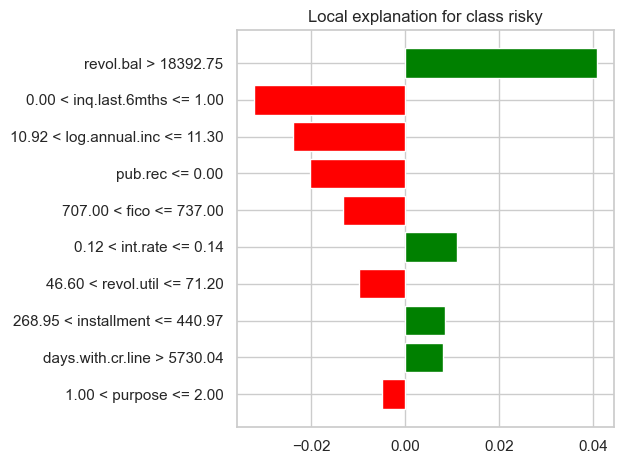

In [105]:
# LIME local explanation for one selected case
lime_explainer = LimeTabularExplainer(
    training_data=np.asarray(X_train_t),
    feature_names=feature_names,
    class_names=['safe', 'risky'],
    mode='classification',
    random_state=RANDOM_SEED
)

case_for_lime = selected_cases[1] if selected_cases else X_val.index[0]
case_pos = X_val.index.get_loc(case_for_lime)
exp = lime_explainer.explain_instance(
    data_row=np.asarray(X_val_t[case_pos]),
    predict_fn=model.predict_proba,
    num_features=10
)
print('LIME case:', case_for_lime)
_ = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

In [106]:
display(val_results.loc[selected_cases])

,y_true,y_prob,y_pred
3627,1,0.006055,0
3015,1,0.296830,0
7992,0,0.824824,1
6962,0,0.301368,1


## M2 Reflection (Write Here)

For each of 3 cases, add:
- Why the model failed
- Which features drove the decision
- Whether the explanation seems plausible to domain stakeholders

**3672: Most confident FN**
1) The customer had good credit signals but still defaulted
2) The model was influenced mostly by int.rate and FICO, negatively downshifting it
3) Makes sense, the model had all reason to believe this was a good customer based on usual credit signals but doesn't have access to non credit risk factors, hence it failed in this case

**7992: Most confident FP**
1) Overstated certain risk signals leading to a false positive as they did not defualt.
2) The model was influenced mostly by inq.last.6mths and interest rate, revolving utilization too a little bit.
3) Usually inquiries and high interest rates are indeed risk signals that is used in credit scoring, hence the model was correct to assume the chance of defaulting and flagging it. In this case it just happened to be a false postive

**3015: Borderline FN**
1) Risk signals were present but were too weak, this was right on the threshold od the model
2) Driving features (SHAP): days with credit line and debt to income ratio (dti). Driving features (LIME): revol.bal and int.rate for risky, inq.last.6mths and log.annual.inc for safe.
3) Partially plausible. SHAP and LIME both agree on int.rate and days.with.cr.line as risky flags, but disagree on revol.util and fico which are pushing towards safe in SHAP but risky in LIME. LIME also does not have the dti in its top 10, although SHAP had it as its second strongest driver.
This was on the cusp of the threshold so it is understanable that it can be a false negative and have this divergence. The dti and credit line should have pushed it over to being flagged, but due to not having any inquiries, and the income it was able to barely offset it to being flagged as safe

**Limitations**
SHAP and LIME describe model behavior, not ground-truth causality. The disagreement in Case 3015 reflects the position right at the decision boundary of 0.297 vs 0.30. Neither method is wrong but indicate that explanations near the threshold should be trusted less than confident cases like 3672 and 7992.

## M3: Global Audit

Deliverable requirements:
1. Global feature ranking.
2. PDP for top numeric drivers.
3. One interaction finding with evidence.

,feature,importance_mean,importance_std
1,int.rate,0.026446,0.006335
9,inq.last.6mths,0.020307,0.006554
2,installment,0.016498,0.007726
12,purpose,0.016304,0.007606
5,fico,0.015872,0.007621
3,log.annual.inc,0.014846,0.008198
8,revol.util,0.008947,0.006307
0,credit.policy,0.005454,0.001577
7,revol.bal,0.005298,0.002427
11,pub.rec,0.002386,0.001225


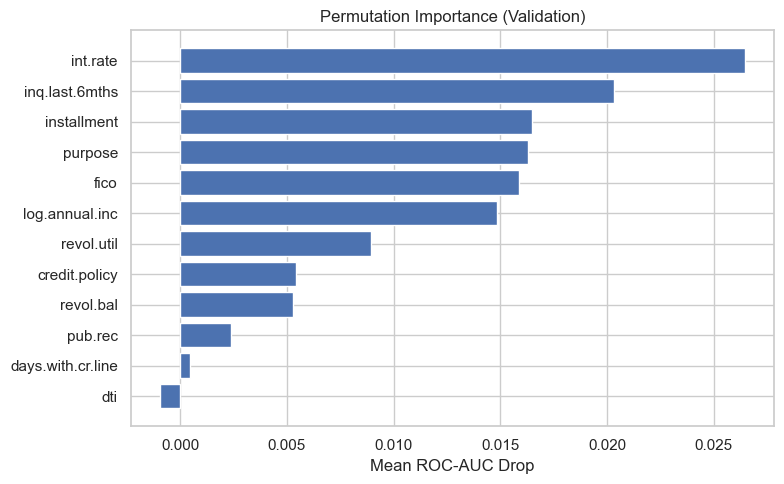

In [107]:
perm = permutation_importance(
    estimator=model,
    X=X_val_t,
    y=y_val,
    n_repeats=8,
    random_state=RANDOM_SEED,
    scoring='roc_auc'
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)
display(importance_df.head(15))

plt.figure(figsize=(8, 5))
top = importance_df.head(12).iloc[::-1]
plt.barh(top['feature'], top['importance_mean'])
plt.title('Permutation Importance (Validation)')
plt.xlabel('Mean ROC-AUC Drop')
plt.tight_layout()
plt.show()

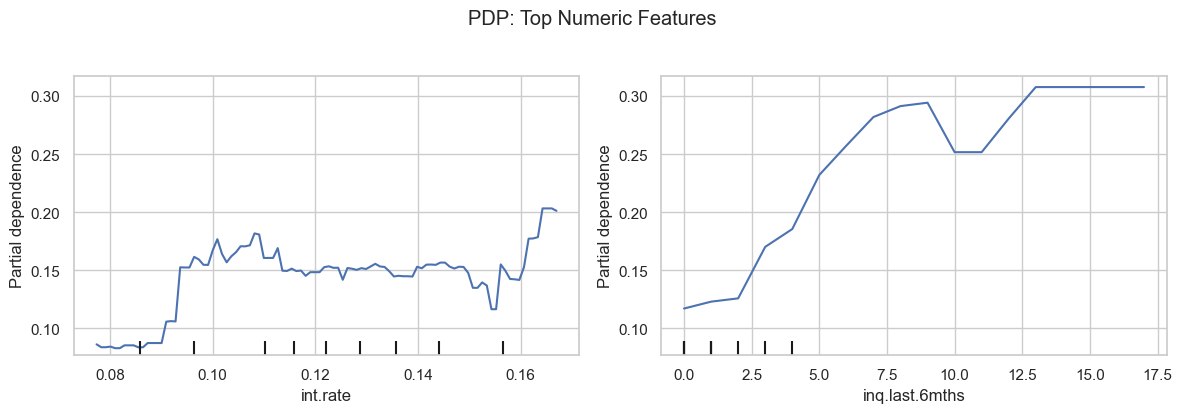

In [108]:
top_numeric = [f for f in importance_df['feature'].tolist() if f in numeric_cols][:2]
if not top_numeric:
    print('No numeric features found for PDP.')
else:
    idxs = [feature_names.index(f) for f in top_numeric]
    fig, ax = plt.subplots(1, len(idxs), figsize=(6 * len(idxs), 4))
    if len(idxs) == 1:
        ax = [ax]
    PartialDependenceDisplay.from_estimator(model, X_val_t, idxs, feature_names=feature_names, ax=ax)
    plt.suptitle('PDP: Top Numeric Features', y=1.03)
    plt.tight_layout()
    plt.show()

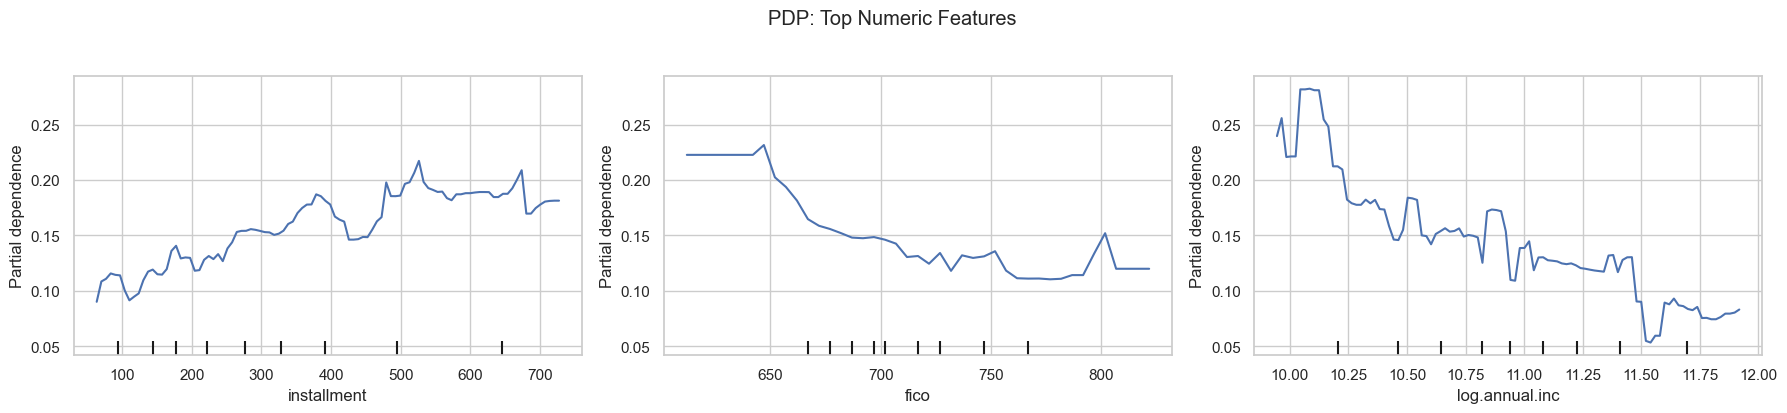

In [109]:
top_numeric = [f for f in importance_df['feature'].tolist() if f in numeric_cols][2:5]
if not top_numeric:
    print('No numeric features found for PDP.')
else:
    idxs = [feature_names.index(f) for f in top_numeric]
    fig, ax = plt.subplots(1, len(idxs), figsize=(6 * len(idxs), 4))
    if len(idxs) == 1:
        ax = [ax]
    PartialDependenceDisplay.from_estimator(model, X_val_t, idxs, feature_names=feature_names, ax=ax)
    plt.suptitle('PDP: Top Numeric Features', y=1.03)
    plt.tight_layout()
    plt.show()

In [110]:
# TODO: Choose two features for interaction analysis and justify your choice in markdown.
candidate_features = importance_df['feature'].head(10).tolist()
print('Top candidates:', candidate_features)

Top candidates: ['int.rate', 'inq.last.6mths', 'installment', 'purpose', 'fico', 'log.annual.inc', 'revol.util', 'credit.policy', 'revol.bal', 'pub.rec']


In [111]:
X_inter = X_val_t[np.random.default_rng(RANDOM_SEED).choice(
    np.arange(X_val_t.shape[0]), size=min(800, X_val_t.shape[0]), replace=False
)]

inter_explainer = shap.TreeExplainer(model)
inter_vals = inter_explainer.shap_interaction_values(X_inter)
if isinstance(inter_vals, list):
    inter_vals = inter_vals[1] if len(inter_vals) > 1 else inter_vals[0]

n_features = len(feature_names)
interaction_matrix = np.abs(inter_vals).mean(axis=0)
np.fill_diagonal(interaction_matrix, 0)

pairs = []
for i in range(n_features):
    for j in range(i+1, n_features):
        pairs.append({
            'feature_a': feature_names[i],
            'feature_b': feature_names[j],
            'mean_abs_interaction': interaction_matrix[i, j]
        })

pairs_df = pd.DataFrame(pairs).sort_values('mean_abs_interaction', ascending=False)
display(pairs_df.head(10))

,feature_a,feature_b,mean_abs_interaction
23,installment,log.annual.inc,0.056155
15,int.rate,fico,0.045001
13,int.rate,log.annual.inc,0.043471
28,installment,revol.util,0.041607
37,log.annual.inc,revol.util,0.038747
22,int.rate,purpose,0.038347
63,revol.bal,revol.util,0.036901
35,log.annual.inc,days.with.cr.line,0.036688
18,int.rate,revol.util,0.036016
33,log.annual.inc,dti,0.035214


SHAP mean |interaction| between installment and log.annual.inc: 0.05615


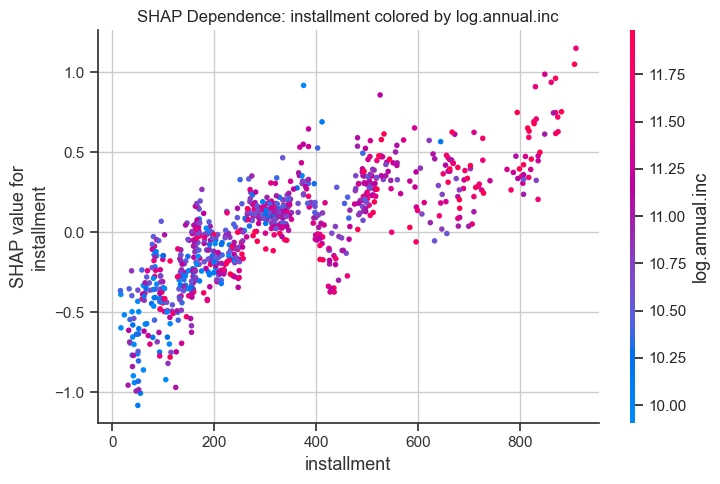

In [112]:
feature_a = 'installment'  # TODO set, e.g., 'dti'
feature_b = 'log.annual.inc'  # TODO set, e.g., 'annual_inc'

if feature_a is None or feature_b is None:
    raise ValueError('Set feature_a and feature_b before running interaction analysis.')

if feature_a not in feature_names or feature_b not in feature_names:
    raise ValueError('Chosen features must be present in feature_names.')

i1, i2 = feature_names.index(feature_a), feature_names.index(feature_b)
X_inter = X_val_t[np.random.default_rng(RANDOM_SEED).choice(np.arange(X_val_t.shape[0]), size=min(800, X_val_t.shape[0]), replace=False)]

inter_explainer = shap.TreeExplainer(model)
inter_vals = inter_explainer.shap_interaction_values(X_inter)
if isinstance(inter_vals, list):
    inter_vals = inter_vals[1] if len(inter_vals) > 1 else inter_vals[0]

strength = np.abs(inter_vals[:, i1, i2]).mean()
print(f'SHAP mean |interaction| between {feature_a} and {feature_b}: {strength:.5f}')
shap.dependence_plot(i1, inter_explainer.shap_values(X_inter), X_inter, feature_names=feature_names, interaction_index=i2, show=False)
plt.title(f'SHAP Dependence: {feature_a} colored by {feature_b}')
plt.tight_layout()
plt.show()

SHAP mean |interaction| between log.annual.inc and installment: 0.05615


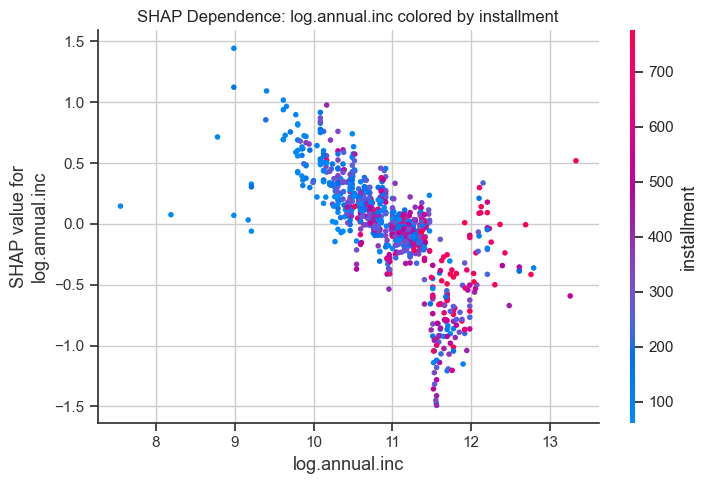

In [113]:
feature_a = 'log.annual.inc'  # TODO set, e.g., 'dti'
feature_b = 'installment'  # TODO set, e.g., 'annual_inc'

if feature_a is None or feature_b is None:
    raise ValueError('Set feature_a and feature_b before running interaction analysis.')

if feature_a not in feature_names or feature_b not in feature_names:
    raise ValueError('Chosen features must be present in feature_names.')

i1, i2 = feature_names.index(feature_a), feature_names.index(feature_b)
X_inter = X_val_t[np.random.default_rng(RANDOM_SEED).choice(np.arange(X_val_t.shape[0]), size=min(800, X_val_t.shape[0]), replace=False)]

inter_explainer = shap.TreeExplainer(model)
inter_vals = inter_explainer.shap_interaction_values(X_inter)
if isinstance(inter_vals, list):
    inter_vals = inter_vals[1] if len(inter_vals) > 1 else inter_vals[0]

strength = np.abs(inter_vals[:, i1, i2]).mean()
print(f'SHAP mean |interaction| between {feature_a} and {feature_b}: {strength:.5f}')
shap.dependence_plot(i1, inter_explainer.shap_values(X_inter), X_inter, feature_names=feature_names, interaction_index=i2, show=False)
plt.title(f'SHAP Dependence: {feature_a} colored by {feature_b}')
plt.tight_layout()
plt.show()

SHAP mean |interaction| between fico and int.rate: 0.04500


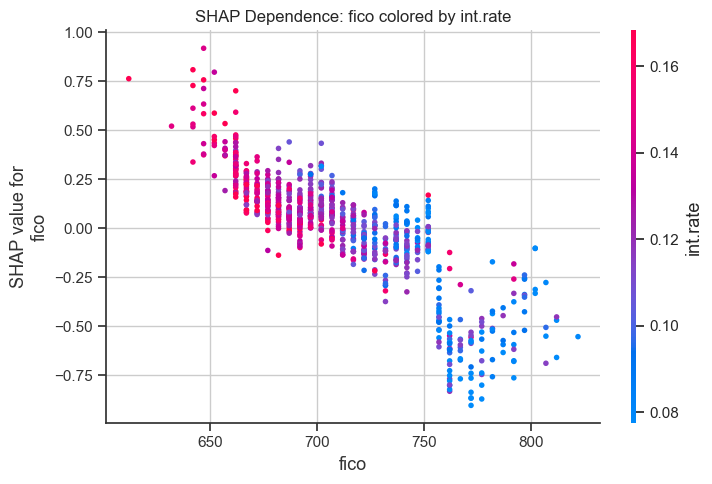

In [114]:
feature_a = 'fico'  # TODO set, e.g., 'dti'
feature_b = 'int.rate'  # TODO set, e.g., 'annual_inc'

if feature_a is None or feature_b is None:
    raise ValueError('Set feature_a and feature_b before running interaction analysis.')

if feature_a not in feature_names or feature_b not in feature_names:
    raise ValueError('Chosen features must be present in feature_names.')

i1, i2 = feature_names.index(feature_a), feature_names.index(feature_b)
X_inter = X_val_t[np.random.default_rng(RANDOM_SEED).choice(np.arange(X_val_t.shape[0]), size=min(800, X_val_t.shape[0]), replace=False)]

inter_explainer = shap.TreeExplainer(model)
inter_vals = inter_explainer.shap_interaction_values(X_inter)
if isinstance(inter_vals, list):
    inter_vals = inter_vals[1] if len(inter_vals) > 1 else inter_vals[0]

strength = np.abs(inter_vals[:, i1, i2]).mean()
print(f'SHAP mean |interaction| between {feature_a} and {feature_b}: {strength:.5f}')
shap.dependence_plot(i1, inter_explainer.shap_values(X_inter), X_inter, feature_names=feature_names, interaction_index=i2, show=False)
plt.title(f'SHAP Dependence: {feature_a} colored by {feature_b}')
plt.tight_layout()
plt.show()

## M3 Reflection (Write Here)

- What are the top 3 globally important features?
- Which PDP patterns look non-linear?
- What hidden interaction rule did you find?

1. The top 3 features were, int.rate (0.026), inq.last.6mths (0.02), and installment (0.016). interest rate and recent credit inquiries showcased that they were much more important

2. From the top 2 numeric features, int.rate showed a step like pattern raather than a smooth linear trend. It jumped from flat to 0.15 around the 9.5% and then plateaus till 16% till it jumps again. The inq.last.6mths is more continuous and rises steadily before plateauing past 13 inquiries. Showcasing greater effect between 0 and the first few inquiries, until later having more has less of an increase in effect.

3. installment and log.annual.inc had the greatest pairwise interaction of 0.056. The same installment amount prodcuces different risk contributions depending on income. High income only has a greater reduction in risk if the corresponding installment is also manageable. Which makes sense, as an installment has different affects depending on the income of a person.

We also checked the second ranked pair of int.rate and fico, but there was less independent variation and more of a correlated behaviour. Mostly due to the fico store contirbuting to the income rate given to an individual.

## M4: Slicing Analysis and Audit Report

Deliverable requirements:
1. Choose subgroup column(s) and report per-group metrics.
2. Identify one group with significant performance weakness.
3. Propose a practical fix (data vs features vs both).

In [115]:
slice_candidates = ['home_ownership', 'purpose', 'grade', 'sub_grade', 'emp_length', 'addr_state', 'verification_status']
available = [c for c in slice_candidates if c in X_val.columns]
print('Available slice columns:', available)

# Only `purpose` is here as an available column to slice on. We use purpose as the applicant-segment slice, and add an
# engineered fico_band (credit-quality quartile) as a second slice since FICO is
# a core credit-risk dimension and gives a more informative risk-concentration view.
slice_col = 'purpose'

if slice_col is None:
    raise ValueError('Set slice_col to one of the available slice columns.')
print('Chosen slice column:', slice_col)

X_val['fico_band'] = pd.qcut(X_val['fico'], q=4, labels=['low', 'mid_low', 'mid_high', 'high'])
print(X_val['fico_band'].value_counts().sort_index())


Available slice columns: ['purpose']
Chosen slice column: purpose
fico_band
low         527
mid_low     437
mid_high    501
high        451
Name: count, dtype: int64


In [116]:
tmp = pd.DataFrame({
    'group': X_val[slice_col].astype(str).fillna('missing'),
    'y_true': y_val.values,
    'y_prob': val_proba
})
tmp['y_pred'] = (tmp['y_prob'] >= threshold).astype(int)

rows = []
for g, part in tmp.groupby('group'):
    if len(part) < 50:
        continue
    auc = roc_auc_score(part['y_true'], part['y_prob']) if part['y_true'].nunique() > 1 else np.nan
    f1 = f1_score(part['y_true'], part['y_pred']) if part['y_true'].nunique() > 1 else np.nan
    actual_pos = (part['y_true'] == 1).sum()
    fn = ((part['y_true'] == 1) & (part['y_pred'] == 0)).sum()
    fnr = fn / actual_pos if actual_pos > 0 else np.nan  # false negative rate: missed defaults within group
    rows.append({
        'group': g,
        'n': len(part),
        'positive_rate': part['y_true'].mean(),
        'auc': auc,
        'f1': f1,
        'fnr': fnr
    })

slice_report = pd.DataFrame(rows).sort_values('fnr', ascending=False, na_position='last')
display(slice_report)


,group,n,positive_rate,auc,f1,fnr
1,credit_card,246,0.121951,0.733796,0.142857,0.900000
5,major_purchase,86,0.104651,0.611833,0.142857,0.888889
2,debt_consolidation,802,0.167082,0.566069,0.230000,0.828358
0,all_other,469,0.155650,0.657188,0.233333,0.808219
3,educational,65,0.215385,0.633053,0.333333,0.714286
4,home_improvement,127,0.157480,0.767757,0.375000,0.700000
6,small_business,121,0.223140,0.566982,0.307692,0.629630


In [117]:
tmp_fico = pd.DataFrame({
    'group': X_val['fico_band'],
    'y_true': y_val.values,
    'y_prob': val_proba
})
tmp_fico['y_pred'] = (tmp_fico['y_prob'] >= threshold).astype(int)

rows_fico = []
for g, part in tmp_fico.groupby('group'):
    auc = roc_auc_score(part['y_true'], part['y_prob']) if part['y_true'].nunique() > 1 else np.nan
    f1 = f1_score(part['y_true'], part['y_pred']) if part['y_true'].nunique() > 1 else np.nan
    actual_pos = (part['y_true'] == 1).sum()
    fn = ((part['y_true'] == 1) & (part['y_pred'] == 0)).sum()
    fnr = fn / actual_pos if actual_pos > 0 else np.nan
    rows_fico.append({
        'group': g,
        'n': len(part),
        'positive_rate': part['y_true'].mean(),
        'auc': auc,
        'f1': f1,
        'fnr': fnr
    })

fico_slice_report = pd.DataFrame(rows_fico)
display(fico_slice_report)


,group,n,positive_rate,auc,f1,fnr
0,low,527,0.214421,0.615237,0.298077,0.725664
1,mid_low,437,0.194508,0.558757,0.232558,0.823529
2,mid_high,501,0.149701,0.570360,0.205607,0.853333
3,high,451,0.075388,0.664621,0.150943,0.882353


In [118]:
# Risk concentration: does a group account for a larger share of missed defaults
# than its share of actual risky borrowers? concentration_ratio > 1 means errors
# are concentrated in that group relative to its underlying risk exposure.
total_fn = ((tmp['y_true'] == 1) & (tmp['y_pred'] == 0)).sum()
total_pos = (tmp['y_true'] == 1).sum()

concentration_rows = []
for g, part in tmp.groupby('group'):
    grp_fn = ((part['y_true'] == 1) & (part['y_pred'] == 0)).sum()
    grp_pos = (part['y_true'] == 1).sum()
    concentration_rows.append({
        'group': g,
        'share_of_total_fn': grp_fn / total_fn if total_fn else np.nan,
        'share_of_total_positives': grp_pos / total_pos if total_pos else np.nan,
    })

concentration_df = pd.DataFrame(concentration_rows)
concentration_df['concentration_ratio'] = (
    concentration_df['share_of_total_fn'] / concentration_df['share_of_total_positives']
)
display(concentration_df.sort_values('concentration_ratio', ascending=False, na_position='last'))


,group,share_of_total_fn,share_of_total_positives,concentration_ratio
1,credit_card,0.109756,0.097720,1.123171
5,major_purchase,0.032520,0.029316,1.109304
2,debt_consolidation,0.451220,0.436482,1.033764
0,all_other,0.239837,0.237785,1.008631
3,educational,0.040650,0.045603,0.891405
4,home_improvement,0.056911,0.065147,0.873577
6,small_business,0.069106,0.087948,0.785757


## M4 Reflection (Write Here)

- Which group(s) show the weakest performance and the highest risk concentration?
- Is the failure pattern driven by data volume, feature gaps, or genuine risk differences?
- What practical fix do you propose, and what is the trade-off?

**By purpose (applicant segment):** `credit_card` is the weakest large group: FNR = 0.90 and F1 = 0.143 despite a respectable AUC (0.734), meaning the model can rank-order risk reasonably well within this segment but the chosen threshold still misses 9 of 10 true defaults. `debt_consolidation` is the largest group (n=802, 44% of all positives) and has the lowest AUC among sizeable groups (0.566), so it is the biggest absolute source of missed defaults even though its FNR (0.83) is not the worst.

**By fico_band (fico divided into quartiles):** FNR rises simultaneously with FICO `low` = 0.73 up to `high` = 0.88 while the positive rate falls from 0.21 to 0.075. In other words, the better a borrower's credit profile looks on paper, the more likely the model is to miss them when they do default. This matches the M2 case : a borrower with strong FICO/int.rate signals defaulted anyway, and the model had no feature capturing behavior outside the standard credit-bureau signals.

**Risk concentration:** `credit_card` and `major_purchase` both show concentration_ratio > 1.1, they generate a larger share of total false negatives (11.0%, 3.3%) than their share of actual defaulters (9.8%, 2.9%). `debt_consolidation` and `all_other` are roughly proportional (~1.0), and `small_business` is under-represented in errors (0.79).

**Diagnosis:** This looks like a feature gap rather than a pure data-volume problem. `credit.policy`, `fico`, and `int.rate` mostly encode the initial underwriting decision, so once a borrower clears that bar the model has little left to distinguish who will still default, which is exactly why error rates concentrate in the best-looking (`high` fico_band) and most common (`credit_card`) segments. Small groups (`educational` n=65, `major_purchase` n=86) should be read with caution given limited sample size.

**Proposed fix:** Combined data + feature approach (1) feature: add post-origination behavioral signals (e.g. payment trend, utilization trend) if available, since static bureau features can't explain why a "safe-looking" borrower defaults; (2) data/decision: apply a segment-specific lower threshold for `credit_card` and `high` fico_band, where the model is currently most likely to under-flag.

**Trade-off:** Lowering the threshold for `high` fico_band would catch more of the rare defaults there, but that segment has the lowest base positive rate (7.5%), so it would also generate the most additional false positives per default caught, basically, flagging many genuinely safe high-credit customers for review. This is a precision cost the business must accept to reduce concentrated risk exposure.

**Limitation:** No causal explanation, only correlation, The concentration numbers show that certain groups have disproportionate missed defaults, not why. There could be some other unmeasured factor (e.g. loan size, time period) that's actually driving the effect and just happens to correlate with purpose or fico_band.

### Robustness check
**purpose:**
partially robust: credit_card stays worst/tied-worst at both thresholds 0.90 to 1.00, but home_improvement jumps from rank 6 to tied-worst, so the full ranking isn't stable. Major purpose remaind the same, maybe due to to being speparated by extreme values opposed to threshold ambiguous.

**fico_band:**
not robust: the clean FNR gradient 0.73 to 0.88 by credit quality, converts into a narrow uniformly poor range 0.94 to 0.97 at 0.5 threshold, and low is no longer the best band. We downgrade this from a confident finding to a threshold of 0.3 specific observation.

**Implication:** credit_card is retained as the primary, robust finding; the fico_band gradient is reported with this alteration rather than as a stable model property.

In [119]:
def fnr_by_group(group_col, thresh, min_n=50):
    tmp = pd.DataFrame({'group': X_val[group_col].astype(str), 'y_true': y_val.values, 'y_prob': val_proba})
    tmp['y_pred'] = (tmp['y_prob'] >= thresh).astype(int)
    g = tmp.groupby('group').apply(lambda p: pd.Series({
        'n': len(p),
        'fnr': ((p.y_true==1)&(p.y_pred==0)).sum() / max((p.y_true==1).sum(), 1)
    }))
    return g[g.n >= min_n]

for col in ['purpose', 'fico_band']:
    compare = fnr_by_group(col, 0.3).rename(columns={'fnr':'fnr_t0.3'}).join(
        fnr_by_group(col, 0.5)['fnr'].rename('fnr_t0.5'))
    print(f'{col}:')
    display(compare.sort_values('fnr_t0.3', ascending=False))

purpose:


,n,fnr_t0.3,fnr_t0.5
group,,,
credit_card,246.0,0.900000,1.000000
major_purchase,86.0,0.888889,0.888889
debt_consolidation,802.0,0.828358,0.977612
all_other,469.0,0.808219,0.958904
educational,65.0,0.714286,0.857143
home_improvement,127.0,0.700000,1.000000
small_business,121.0,0.629630,0.814815


fico_band:


,n,fnr_t0.3,fnr_t0.5
group,,,
high,451.0,0.882353,0.941176
mid_high,501.0,0.853333,0.973333
mid_low,437.0,0.823529,0.952941
low,527.0,0.725664,0.946903


## Final Audit Report (Write Here)

Use this exact structure:
1. Executive Summary (5-8 lines)
2. M1 Findings: model quality and threshold rationale
3. M2 Findings: 3 local failure case explanations
4. M3 Findings: global importance, PDP, interaction rule
5. M4 Findings: subgroup failure and risk concentration
6. Recommended Fix: data vs feature vs combined
7. Limitations and Monitoring Plan

### 1. Executive Summary

We audited a LightGBM credit-risk classifier trained on LendingClub loan
data, with a specific focus on whether false negative rates (missed
defaults) are unfairly concentrated across applicant subgroups. An initial
model achieved a suspicious perfect F1 = 1.0; we traced this to target
leakage from not.fully.paid and rebuilt the model without it, producing
a realistic baseline (ROC-AUC 0.636, F1 0.245 at threshold 0.3). Local
case analysis showed the model relies heavily on standard credit-bureau
signals and fails when a borrower looks safe on paper but defaults anyway.
Global analysis confirmed int.rate, inq.last.6mths, and installment
as the dominant drivers, and found a genuine interaction: a fixed
installment payment is riskier at low income than high income. Subgroup
slicing found credit_card applicants to be a robust, threshold-stable
weak segment, while an initially promising FICO-based gradient did not
survive a robustness check and was downgraded accordingly. We recommend
adding post-origination behavioral features where available and applying
a segment-specific lower threshold for credit_card applicants, accepting
a precision trade-off in exchange for reduced concentrated risk exposure.


### 2. M1 Findings: Model Quality and Threshold Rationale

**Claim:** Threshold 0.3 is operationally preferable to the original 0.5
placeholder, and the model's underlying predictive power is modest but
genuine i.e. not leakage.

**Evidence:** Threshold table showed F1 falling from 0.245 (threshold 0.3)
to 0.044 (threshold 0.6). Confusion matrix at 0.5 caught only 14/307
defaults (recall 4.6%) versus 61/307 at 0.3 (recall 19.8%). An initial run
without excluding not.fully.paid produced a perfect F1 = 1.0, which then a crosstab
against the target confirmed not.fully.paid is a near-exact restatement
of loan outcome. After removal, validation ROC-AUC settled at 0.636.

**Interpretation:** At 0.5 the model is far too conservative for a
screening tool, missing 95% of true defaults is not useful when the cost
of a missed default exceeds the cost of an unnecessary review. ROC-AUC of
0.636 is modest but realistic for 13 pre-origination features with no
tuning, and is a legit baseline once leakage is removed.

**Decision implication:** Threshold was set to 0.3 for all subsequent
milestones. This choice directly shapes which cases appear as failures in
M2 and which subgroup FNRs are reported in M4, it is a big operational decision in the audit.

**Limitation:** Even at the improved threshold, the model still misses
~80% of true defaults and two-thirds of flags are false alarms. Threshold
0.3 was chosen by inspection of a limited grid (0.3-0.6), a wider grid or
explicit cost weighting could surface a different optimum.

### 3. M2 Findings: Local Failure Case Explanations

**Claim:** The model's most damaging error type — confident false
negatives, these occur when a borrower has strong standard credit-bureau
signals (high FICO, low interest rate) but defaults anyway, indicating a
feature gap rather than a reasoning error.

**Evidence:** Four cases spanning both error types and confidence levels
were explained with SHAP (all cases) and LIME (Case 3015). Case 3672
(pred_risk = 0.006, defaulted) was driven almost entirely by int.rate
and fico pushing risk down. Case 7992 (pred_risk = 0.825, repaid) was
driven by inq.last.6mths and int.rate pushing risk up. Case 3015
(pred_risk = 0.297, defaulted) showed moderate, mixed drivers and a
direct SHAP/LIME disagreement on revol.util, fico, and dti.

**Interpretation:** Cases 3672 and 7992 are individually plausible since the
model used standard, sensible risk signals in the expected direction in
both cases. The failures are not reasoning errors but information gaps, meaning
the model has no feature representing why a seemingly creditworthy
borrower might still default (job loss, medical event, etc.).

**Decision implication:** Local case evidence directly motivated the M4
subgroup slice on fico_band, testing whether this "good credit but still
defaults" pattern is concentrated in particular borrower segments rather
than scattered randomly.

**Limitation:** SHAP and LIME describe model behavior, not ground-truth
causality. The disagreement in Case 3015 reflects its position right at
the decision boundary (0.297 vs 0.30). Neither method is wrong, but it
indicates explanations near the threshold should be trusted less than
confident cases like 3672 and 7992.

### 4. M3 Findings: Global Importance, PDP, and Interaction Rule

**Claim:** int.rate, inq.last.6mths, and installment are the
model's dominant global drivers, and installment's risk contribution is
not independent, it depends on income, a  learned interaction
rather than two features acting additively.

**Evidence:** Permutation importance ranked int.rate (0.026),
inq.last.6mths (0.020), and installment (0.016) above all other
features. fico ranked 5th despite the prominence in M2. PDP showed
int.rate has a non-linear, step-like shape (flat below ~9%, plateau from
~9.5%, jump above ~16%). SHAP interaction values ranked installment x
log.annual.inc highest (0.056) of all feature pairs. Dependence plots
showed the same installment value produces different SHAP contributions
depending on income level. A second candidate pair, int.rate x fico
(0.045), was checked and showed minimal independent color variation in
its dependence plot, indicating collinearity rather than a true
interaction.

**Interpretation:** A feature can dominate specific local cases (fico in
M2) without being the top global driver. Local and global views answer
different questions. The installment/income interaction reflects an
affordability effect, a fixed payment is a heavier burden at low income,
which the model has implicitly learned despite never being given an
explicit payment-to-income ratio feature.

**Decision implication:** Because installment's risk effect is
income-dependent, any future business rule or model simplification based
on installment alone (e.g. a flat installment cutoff) would misclassify
risk across income groups. Any interpretable rule extracted from this
model must condition on income, not installment in isolation.

**Limitation:** PDP and SHAP interaction values describe correlational
structure the model has learned, not a verified causal relationship.
The int.rate x fico collinearity check shows that a high interaction
score alone does not confirm a genuine behavioral interaction, visual
inspection was required to distinguish the two, and this distinction may
not generalize to other unchecked pairs in the feature set.

### 5. M4 Findings: Subgroup Failure and Risk Concentration

**Claim:** credit_card applicants are a robust, threshold-stable
high-risk segment for missed defaults. An apparent FICO-quality gradient
in false negative rate is not robust and should not be treated as a
stable model property.

**Evidence:** Slicing by purpose showed credit_card with FNR = 0.90,
F1 = 0.143 despite AUC = 0.734 at threshold 0.3, and a concentration
ratio > 1.1 (disproportionate share of false negatives vs. its share of
actual defaulters). An engineered fico_band slice showed FNR rising
from 0.73 (low) to 0.88 (high) at threshold 0.3. A robustness check
at threshold 0.5 showed credit_card remained worst/tied-worst (FNR 0.90
to 1.00), but the fico_band gradient collapsed into a narrow, uniformly
poor range (0.94-0.97) with low no longer the best band.

**Interpretation:** The credit_card weakness is a genuine, stable model
property. It persists regardless of operating threshold. The fico_band
gradient,  is threshold dependent. With stricter thresholds the
model misses nearly all defaults across every credit tier, flattening any
apparent subgroup differentiation. Treating it as a stable finding would
have overstated the audit's conclusions.

**Decision implication:** Only the credit_card finding is reported as
an actionable, confirmed risk-concentration result. It is the basis for
the segment-specific threshold recommendation below. The fico_band
result is retained only as a caveated, threshold 0.3 specific observation
and should not independently drive a remediation decision.

**Limitation:** Findings are correlational. Concentration in credit_card
may partly reflect an unmeasured confound (loan size, vintage/time period)
rather than purpose itself. Small subgroups (educational n=65,
major_purchase n=86) should be read with caution given limited sample
size, and only two threshold values (0.3, 0.5) were tested for robustness.

### 6. Recommended Fix: Combined Data and Feature Approach

1. **Feature-level:** add post-origination behavioral signals where
   available (e.g. payment trend, utilization trend over time), since
   static bureau features cannot explain why a safe-looking borrower
   defaults — the root cause identified across M2 and M4.
2. **Decision-level:** apply a segment-specific lower threshold for
   credit_card applicants, the one subgroup weakness confirmed robust
   to threshold changes.

**Trade-off:** lowering the threshold for credit_card will catch more
of that segment's defaults but will also generate more false positives,
flagging genuinely safe customers for review. This precision cost is the
price of reducing concentrated risk exposure in the model's weakest
confirmed segment, and should be weighed against manual review capacity
before deployment.

### 7. Limitations and Monitoring Plan

**Overall limitations:**
- Only 13 pre-origination features were available; the model cannot
  capture behavioral or post-origination risk signals.
- All subgroup and interaction findings are correlational, not causal.
- Small subgroups should be read with caution given limited sample size.
- Robustness was tested at only two thresholds; the fico_band reversal
  shows conclusions can be threshold-sensitive in ways not yet fully
  mapped.

**Monitoring plan:** track FNR by purpose segment on a rolling basis
post-deployment, with credit_card as the primary watch segment given
its robust weak performance. Re-run the threshold-robustness check
whenever the operating threshold is revisited, since this audit
demonstrated that subgroup conclusions can be threshold-dependent and
should not be assumed stable without re-verification.

## Submission Checklist

- [ ] Workbook completed with all milestone reflections
- [ ] Model artifact saved in artifacts/
- [ ] At least 3 local error explanations included
- [ ] At least 1 interaction effect documented
- [ ] Slicing analysis table included
- [ ] Final audit report completed